Overall Portfolio Loss Ratio: 0.5282


C:\Users\DELL 7020\AppData\Local\Temp\ipykernel_17576\990834914.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=make_risk.index, y=make_risk.values, palette='magma')


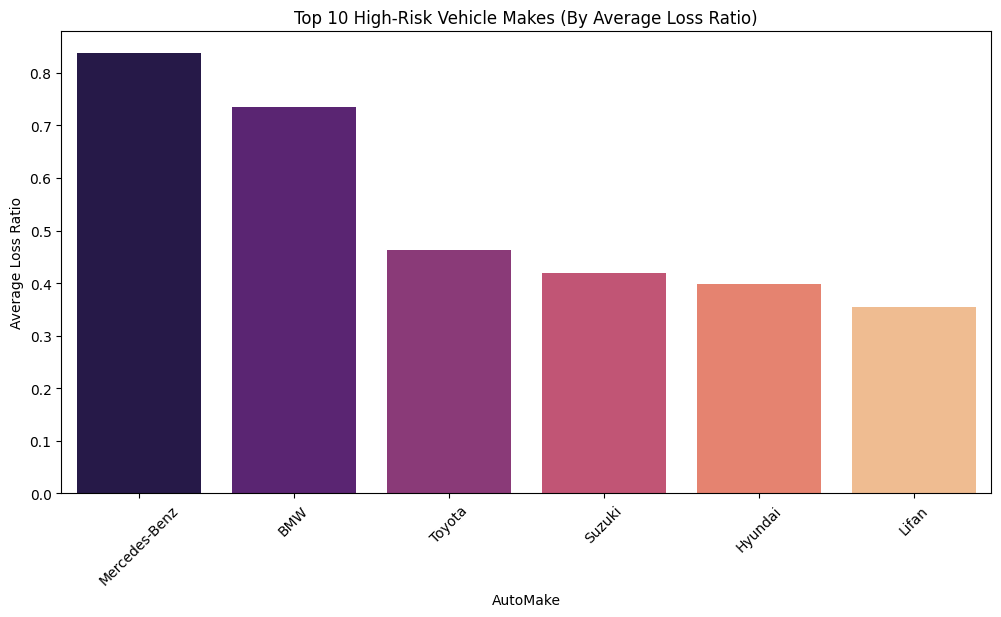

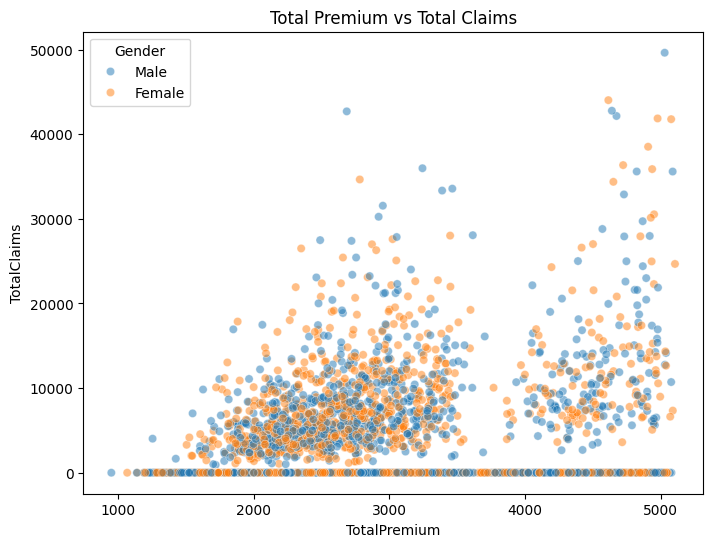

In [ ]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns


sys.path.append(os.path.abspath('../src'))
from data_loader import load_data, clean_data, calculate_metrics

# 1. Load and process
df = load_data('../data/insurance_data.csv')
df = clean_data(df)
df = calculate_metrics(df)

# 2. Check the Loss Ratio 
overall_lr = df['TotalClaims'].sum() / df['TotalPremium'].sum()
print(f"Overall Portfolio Loss Ratio: {overall_lr:.4f}")


plt.figure(figsize=(12, 6))
make_risk = df.groupby('AutoMake')['LossRatio'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=make_risk.index, y=make_risk.values, palette='magma')
plt.title('Top 10 High-Risk Vehicle Makes (By Average Loss Ratio)')
plt.ylabel('Average Loss Ratio')
plt.xticks(rotation=45)
plt.show()

# 4. Creative Plot 2: Premium vs Claims Correlation
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='TotalPremium', y='TotalClaims', hue='Gender', alpha=0.5)
plt.title('Total Premium vs Total Claims')
plt.show()

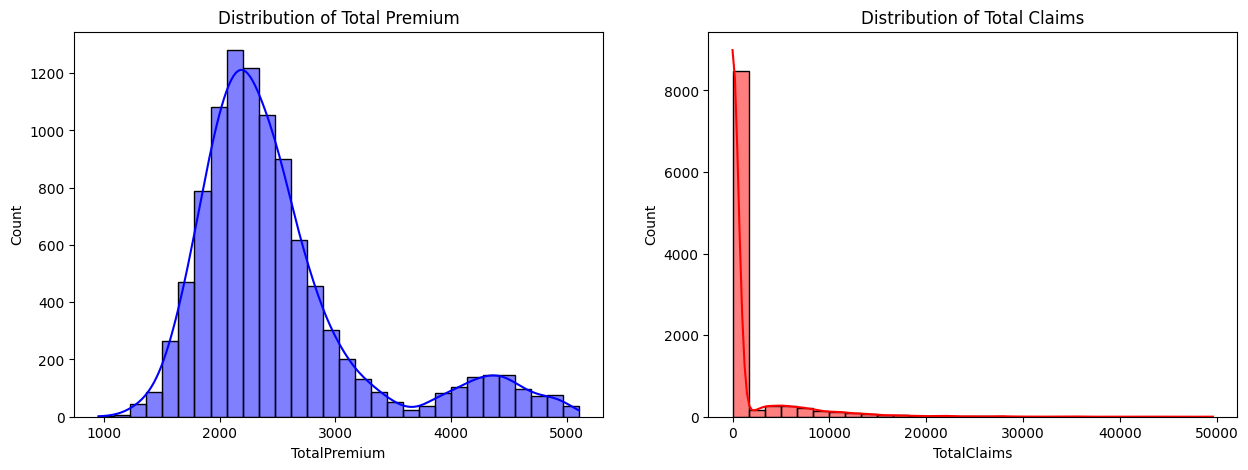

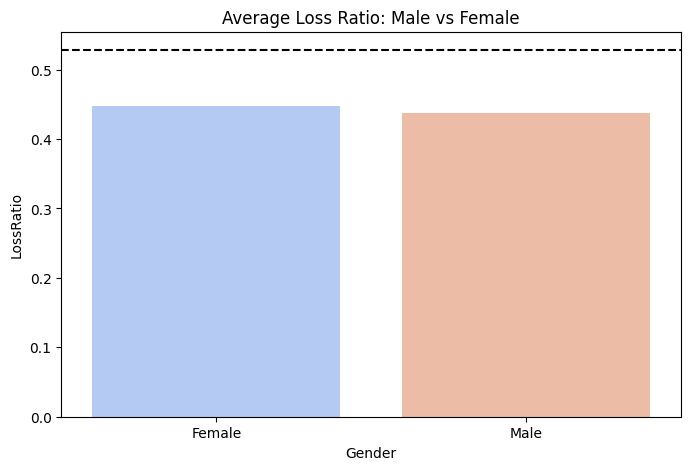

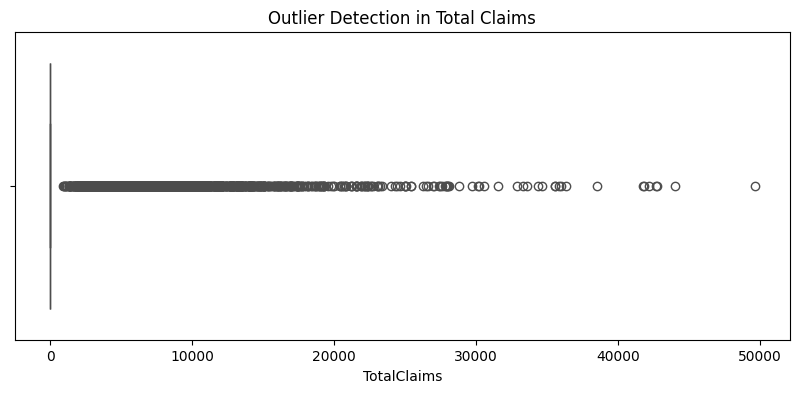

In [3]:
# 1. Distribution of TotalPremium and TotalClaims (Univariate Analysis)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['TotalPremium'], bins=30, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Distribution of Total Premium')

sns.histplot(df['TotalClaims'], bins=30, kde=True, ax=ax[1], color='red')
ax[1].set_title('Distribution of Total Claims')
plt.show()

# 2. Risk by Gender (Bivariate Analysis)
plt.figure(figsize=(8, 5))
gender_risk = df.groupby('Gender')['LossRatio'].mean().reset_index()
sns.barplot(data=gender_risk, x='Gender', y='LossRatio', hue='Gender', palette='coolwarm', legend=False)
plt.axhline(overall_lr, color='black', linestyle='--', label='Portfolio Avg')
plt.title('Average Loss Ratio: Male vs Female')
plt.show()

# 3. Outlier Detection (Boxplot)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['TotalClaims'], color='orange')
plt.title('Outlier Detection in Total Claims')
plt.show()